# Loading packages <a class="anchor" id="Loading-packages"></a>

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

import scanpy as sc
import scvelo as scv
import numpy as np
import cell2location
from cell2location.utils.filtering import filter_genes
from cell2location.models import RegressionModel
import scvi
import pandas as pd

# Plot
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.ndimage import binary_dilation
from scipy.spatial import Delaunay
from scipy.spatial import ConvexHull
from scipy.interpolate import splprep, splev

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs
plt.rcParams['font.family'] = 'Arial' # Set font family to Arial for the entire plot
import logging
from fontTools import subset
logging.getLogger('fontTools.subset').setLevel(logging.ERROR) # Disable INFO messages for fontTools

In [2]:
cell2location.__version__

'0.1.4'

In [2]:
# First, let's define where we save the results of our analysis:
results_folder = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis'

# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/reference_signatures'
run_name = f'{results_folder}/cell2location_map'

# Loading Stereo-seq and scRNA-seq reference data <a class="anchor" id="Loading-Stereo-seq-and-scRNA-seq-reference-data"></a>

## Load the reference signatures

In [3]:
mat = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/Annotation/metadata_snRNA.csv', header=0, index_col=0)
mat = mat[mat['sample2'] == 'GW16']
mat['celltype'] = mat['cell_type_snRNA']
mat = mat[["sample2", "celltype"]]
mat

,sample2,celltype
AAACAGCCAATAATGG-1-5,GW16,Microglia
AAACAGCCAATAGCAA-1-5,GW16,MP
AAACAGCCACCTCAGG-1-5,GW16,COP
AAACAGCCACCTGGTG-1-5,GW16,Microglia
AAACAGCCAGCCTTGG-1-5,GW16,APC_ventral
...,...,...
TTTGTTGGTGTTTGTC-1-5,GW16,ExN_mature_1
TTTGTTGGTTAAGTGT-1-5,GW16,COP
TTTGTTGGTTCGGTAA-1-5,GW16,APC_dorsal
TTTGTTGGTTGCATCT-1-5,GW16,IPC


In [4]:
counts = mat['celltype'].value_counts()
exclude_types = ["Schwann"]
low_count_types = counts[counts < 10].index.tolist()
all_exclude = set(exclude_types + low_count_types)
mat = mat[~mat['celltype'].isin(all_exclude)].copy()
mat

,sample2,celltype
AAACAGCCAATAATGG-1-5,GW16,Microglia
AAACAGCCAATAGCAA-1-5,GW16,MP
AAACAGCCACCTCAGG-1-5,GW16,COP
AAACAGCCACCTGGTG-1-5,GW16,Microglia
AAACAGCCAGCCTTGG-1-5,GW16,APC_ventral
...,...,...
TTTGTTGGTGTTTGTC-1-5,GW16,ExN_mature_1
TTTGTTGGTTAAGTGT-1-5,GW16,COP
TTTGTTGGTTCGGTAA-1-5,GW16,APC_dorsal
TTTGTTGGTTGCATCT-1-5,GW16,IPC


In [5]:
adata_raw = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/1.hscAdata_raw.h5ad')
adata_ref = adata_raw[adata_raw.obs.index.isin(mat.index)]
adata_ref.obs = adata_ref.obs.join(mat)
adata_ref

AnnData object with n_obs × n_vars = 14846 × 36601
    obs: 'Sample', 'batch', 'sample2', 'celltype'
    var: 'gene_ids', 'feature_types'

In [6]:
len(adata_ref.obs['celltype'].value_counts())

36

In [7]:
adata_ref.obs['celltype'].value_counts()

celltype
OPC                  1547
APC_ventral          1226
APC_dorsal           1215
VLMC                  885
COP                   876
APC_cycling           684
ExN_mature_1          642
InN_immature_1        578
IPC                   570
ExN_immature_2        563
InN_mature_1          551
MFOL                  549
Microglia             515
ExN_immature_1        474
NPC_proliferative     469
ExN_ventral           411
MP                    329
InN_ventral_2         261
MN2                   228
EC                    219
InN_immature_2        200
NPC                   192
ExN_mature_2          185
InN_mature_2          183
InN_ventral_3         180
FP                    169
ExN_mature_3          166
ExN_naive             135
PC                    133
InN_ventral_1         128
MOL                   101
RP                     86
ExN_immature_3         63
AST                    53
MN1                    46
InN_naive              34
Name: count, dtype: int64

In [8]:
adata_ref.var['SYMBOL'] = adata_ref.var.index 
# rename 'GeneID-2' as necessary for your data
adata_ref.var.set_index('gene_ids', drop=True, inplace=True)
# Identify genes shared with the spatial dataset
gene_share = adata_ref.var['SYMBOL']
# Create a mapping from gene symbols to `gene_ids`
symbol_to_gene_id = adata_ref.var.reset_index().set_index('SYMBOL')['gene_ids']

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

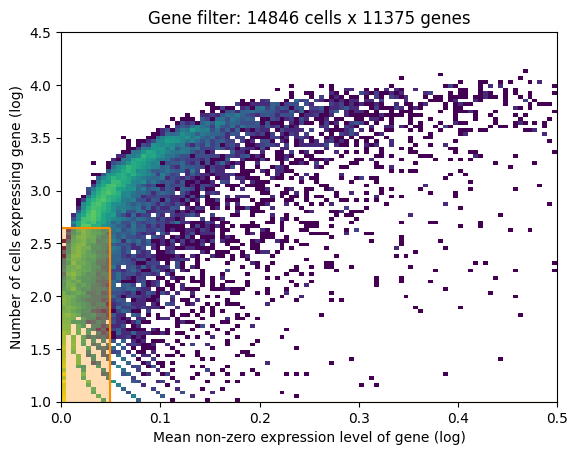

In [9]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
adata_ref = adata_ref[:, selected].copy()

## load the spatial data

In [10]:
adata_bgi = sc.read_h5ad("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/Smooth/H5AD/SeuratObj_gw16.h5ad")
adata_bgi.obsm['spatial'] = adata_bgi.obsm['X_cod']
adata_bgi

AnnData object with n_obs × n_vars = 21039 × 26991
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y'
    var: 'name'
    obsm: 'X_cod', 'spatial'

In [11]:
adata_bgi.obs

,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,cell,x,y
GW16:14640_7380,175.0,89,175.0,89,GW16:14640_7380,14640.0,7380.0
GW16:16980_9060,281.0,157,281.0,157,GW16:16980_9060,16980.0,9060.0
GW16:16530_9420,602.0,308,602.0,308,GW16:16530_9420,16530.0,9420.0
GW16:13710_8340,748.0,381,748.0,381,GW16:13710_8340,13710.0,8340.0
GW16:12900_9690,1147.0,555,1147.0,555,GW16:12900_9690,12900.0,9690.0
...,...,...,...,...,...,...,...
GW16:12840_10560,47.0,29,47.0,29,GW16:12840_10560,12840.0,10560.0
GW16:14760_12270,3.0,2,3.0,2,GW16:14760_12270,14760.0,12270.0
GW16:15420_12180,5.0,4,5.0,4,GW16:15420_12180,15420.0,12180.0
GW16:15810_12090,9.0,5,9.0,5,GW16:15810_12090,15810.0,12090.0


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

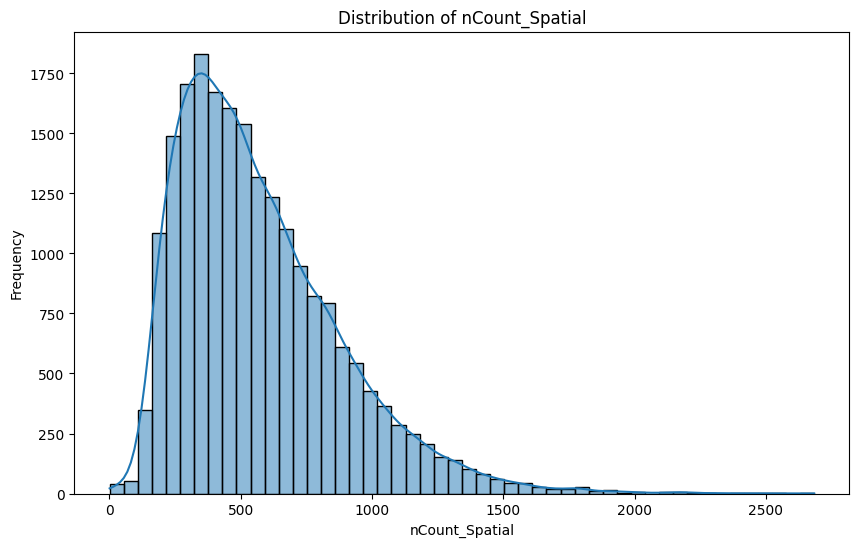

In [12]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(adata_bgi.obs['nCount_Spatial'], bins=50, kde=True)
plt.title('Distribution of nCount_Spatial')
plt.xlabel('nCount_Spatial')
plt.ylabel('Frequency')
plt.show()

In [13]:
adata_bgi = adata_bgi[adata_bgi.obs['nCount_Spatial'] > 300].copy()

In [14]:
adata_bgi

AnnData object with n_obs × n_vars = 17032 × 26991
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y'
    var: 'name'
    obsm: 'X_cod', 'spatial'

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

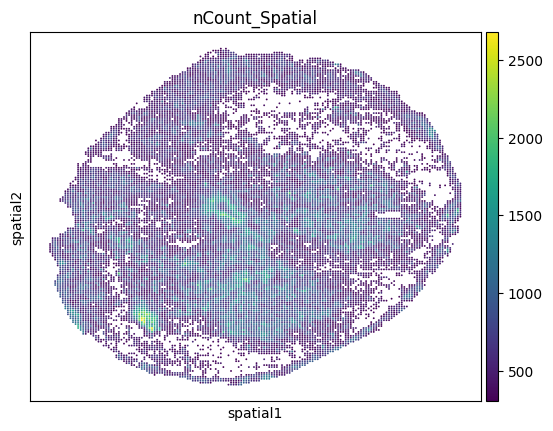

In [15]:
sc.pl.embedding(adata_bgi, basis="spatial", color='nCount_Spatial')

In [16]:
genes_in_data = adata_bgi.var_names.isin(gene_share)
adata_bgi = adata_bgi[:, genes_in_data]
adata_bgi

View of AnnData object with n_obs × n_vars = 17032 × 21021
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y'
    var: 'name'
    obsm: 'X_cod', 'spatial'

In [17]:
# Reset the gene index of `adata_bgi`
adata_bgi.var['SYMBOL'] = adata_bgi.var_names  # Add a gene symbol column
adata_bgi.var.index = adata_bgi.var['SYMBOL'].map(symbol_to_gene_id)  # Use `gene_ids` as the index
adata_bgi.var['gene_ids'] = adata_bgi.var.index
adata_bgi.var.set_index('gene_ids', drop=True, inplace=True)

# Inspect the result
adata_bgi.var

,name,SYMBOL
gene_ids,,
ENSG00000176728,TTTY14,TTTY14
ENSG00000226906,TTTY4,TTTY4
ENSG00000198692,EIF1AY,EIF1AY
ENSG00000183878,UTY,UTY
ENSG00000092377,TBL1Y,TBL1Y
...,...,...
ENSG00000221823,PPP3R1,PPP3R1
ENSG00000131370,SH3BP5,SH3BP5
ENSG00000143947,RPS27A,RPS27A


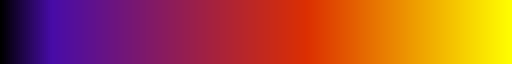

In [18]:
# Visualization setup: update `var` and `obsm`
import pyensembl as en
from pyensembl import EnsemblRelease
import os

os.environ['PYENSEMBL_CACHE_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location'

data = EnsemblRelease(100)

# Define a custom color ramp function
def colorRamp2(colors, positions):
    cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))
    return cmap

# Specify colors and their positions (0 to 1)
positions = [0, 0.1, 0.6, 1]  # Adjust position to shift purple leftward
colors = ['black',  '#480ca8', '#dc2f02', 'yellow']

# Generate the custom colormap
my_custom_colormap = colorRamp2(colors, positions)
my_custom_colormap

#myWR = mcolors.LinearSegmentedColormap.from_list("myWR", ['#64f5f7', '#f589a2',"#f42f5c"], gamma=0.8)
#blueyellow = mcolors.LinearSegmentedColormap.from_list("myWR", [
#"#352A86", "#343296", "#343AA7", "#2646BB", "#1156D0", "#0366DE", "#0A76D8", "#1286D2", "#1C99C0", "#27ADAC", "#46B897", "#78BB7E", "#A9BD67", "#CCBC57", "#EFBA47", "#F7C438", "#F6D12B", "#F6DF1F", "#F7EC16", "#F8FA0D"
#], gamma=0.8)

In [ ]:
# Create the figure and axes
adata = adata_bgi
fig, ax = plt.subplots(figsize=(16, 12))
plt.rcParams['font.family'] = 'Arial'

# Set the gene name and Ensembl ID
gene = "SOX2"
ensembl_id = data.gene_ids_of_gene_name(gene)  # Retrieve the Ensembl ID for this gene

# Extract spatial coordinates
coords = adata.obsm["spatial"]  # Get cell coordinates from the spatial dataset

# Compute the convex hull as the minimal polygon enclosing these points
hull = ConvexHull(coords)
hull_points = coords[hull.vertices]  # Get the vertex coordinates of the convex hull

# Close the hull by appending the first point to the end
hull_points = np.concatenate([hull_points, hull_points[:1]])

# Use Delaunay triangulation to expand the contour and estimate the centroid
tri = Delaunay(coords)
centroid = np.mean(hull_points, axis=0)

# Expand the convex hull boundary to inflate the outline
dilated_points = []
expansion_factor = 100  # Expansion factor (e.g. 100%)

# Extend each point away from the centroid along its direction vector
for point in hull_points[:-1]:
    direction = point - centroid  # Direction vector
    norm = np.linalg.norm(direction)  # Vector length
    if norm > 0:
        direction /= norm  # Normalize the direction vector
        dilated_point = point + direction * expansion_factor  # Expanded point
        dilated_points.append(dilated_point)

dilated_points = np.array(dilated_points)  # Convert expanded points to a NumPy array

# Smooth the expanded contour using spline interpolation
tck, u = splprep([dilated_points[:, 0], dilated_points[:, 1]], s=0.001, per=True)

# Generate additional interpolated points for a smoother curve
smooth_points = splev(np.linspace(0, 1, 1000), tck)

# Plot the spatial scatter map
scv.pl.scatter(
    adata,
    basis="spatial", 
    color=ensembl_id,  # Color cells by gene expression
    color_map=my_custom_colormap,  # Use the custom colormap
    alpha=1,  # Keep points fully opaque
    size=80,  # Point size
    fontsize=24,  # Title font size
    title=gene,  # Use the gene name as the title
    show=False,  # Do not display immediately so the plot can be further customized
    ax=ax  # Draw on the predefined axes
)

# Overlay the smoothed expanded contour
ax.plot(smooth_points[0], smooth_points[1], 'w--', lw=1.5)  # White dashed line with linewidth 1.5

# Set the background color to black
ax.set_facecolor('black')  # Axes background
fig.patch.set_facecolor('black')  # Figure background

# Set the title color to white
ax.set_title(gene, color='white', fontsize=20)

# Customize the colorbar with Min/Max labels only
cbar = ax.collections[0].colorbar  # Get the colorbar from the first plotted layer
cbar.set_ticks([])  # Remove the default ticks
cbar.ax.text(0.5, 1.05, 'Max', color='white', ha='center', fontsize=16, transform=cbar.ax.transAxes)  # Top label
cbar.ax.text(0.5, -.1, 'Min', color='white', ha='center', fontsize=16, transform=cbar.ax.transAxes)  # Bottom label

# Save the result as a PDF file
plt.savefig("SOX2_expression.pdf", format='pdf')
plt.show()

In [18]:
# find mitochondria-encoded (MT) genes
adata_bgi.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_bgi.var['SYMBOL']]

# remove MT genes for spatial mapping (keeping their counts in the object)
adata_bgi.obsm['MT'] = adata_bgi[:, adata_bgi.var['MT_gene'].values].X.toarray()
adata_bgi = adata_bgi[:, ~adata_bgi.var['MT_gene'].values]

# Estimation of reference cell type signatures (NB regression) <a class="anchor" id="Estimation-of-reference-cell-type-signatures-(NB-regression)"></a>

In [19]:
adata_ref.obs

,Sample,batch,sample2,celltype
AAACAGCCAATAATGG-1-5,GW16,5,GW16,Microglia
AAACAGCCAATAGCAA-1-5,GW16,5,GW16,MP
AAACAGCCACCTCAGG-1-5,GW16,5,GW16,COP
AAACAGCCACCTGGTG-1-5,GW16,5,GW16,Microglia
AAACAGCCAGCCTTGG-1-5,GW16,5,GW16,APC_ventral
...,...,...,...,...
TTTGTTGGTGTTTGTC-1-5,GW16,5,GW16,ExN_mature_1
TTTGTTGGTTAAGTGT-1-5,GW16,5,GW16,COP
TTTGTTGGTTCGGTAA-1-5,GW16,5,GW16,APC_dorsal
TTTGTTGGTTGCATCT-1-5,GW16,5,GW16,IPC


In [20]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref, 
                        # 10X reaction / sample / batch
                        batch_key='sample2', 
                        # cell type, covariate used for constructing signatures
                        labels_key='celltype'
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                        #categorical_covariate_keys=['Method']
                       )

In [21]:
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref) 

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.2.0.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample2',
│   'labels_key': 'celltype',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 14846 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  36   │
│          n_vars          │ 11375 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample2'] │    GW16    │          0          │
└──────────────────────┴────────────┴─────────────────────┘

                       labels State Registry                       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃    Categories     ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['celltype'] │    APC_cycling    │          0          │
│                       │    APC_dorsal     │          1          │
│                       │    APC_ventral    │          2          │
│                       │        AST        │          3          │
│                       │        COP        │          4          │
│                       │        EC         │          5          │
│                       │  ExN_immature_1   │          6          │
│                       │  ExN_immature_2   │          7          │
│                       │  ExN_immature_3   │          8          │
│                       │   ExN_mature_1    │          9          │
│                       │   ExN_mature_2    │         10          │
│                       │   ExN_mature_3    │         11          │
│                       │     ExN_naive     │         12          │
│                       │    ExN_ventral    │         13          │
│                       │        FP         │         14          │
│                       │        IPC        │         15          │
│                       │  InN_immature_1   │         16          │
│                       │  InN_immature_2   │         17          │
│                       │   InN_mature_1    │         18          │
│                       │   InN_mature_2    │         19          │
│                       │     InN_naive     │         20          │
│                       │   InN_ventral_1   │         21          │
│                       │   InN_ventral_2   │         22          │
│                       │   InN_ventral_3   │         23          │
│                       │       MFOL        │         24          │
│                       │        MN1        │         25          │
│                       │        MN2        │         26          │
│                       │        MOL        │         27          │
│                       │        MP         │         28          │
│                       │     Microglia     │         29          │
│                       │        NPC        │         30          │
│                       │ NPC_proliferative │         31          │
│                       │        OPC        │         32          │
│                       │        PC         │         33          │
│                       │        RP         │         34          │
│                       │       VLMC        │         35          │
└───────────────────────┴───────────────────┴─────────────────────┘

In [22]:
mod.train(max_epochs=1000) # ,use_gpu=True

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A30') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

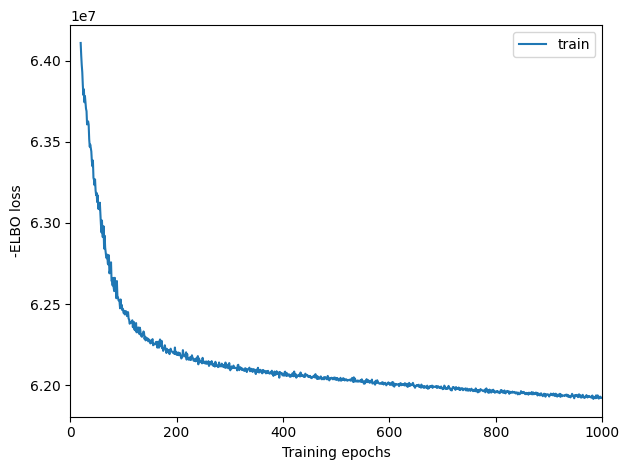

In [23]:
mod.plot_history(20)

In [24]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500} #, 'use_gpu': True
)

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/sc_gw16.h5ad"
adata_ref.write(adata_file)
adata_file

Sampling local variables, batch:   0%|          | 0/6 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis/reference_signatures/sc_gw16.h5ad'

In [25]:
adata_ref = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis/reference_signatures/sc_gw16.h5ad')
adata_ref

AnnData object with n_obs × n_vars = 14846 × 11375
    obs: 'Sample', 'batch', 'sample2', 'celltype', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'feature_types', 'SYMBOL', 'n_cells', 'nonz_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    varm: 'means_per_cluster_mu_fg', 'q05_per_cluster_mu_fg', 'q95_per_cluster_mu_fg', 'stds_per_cluster_mu_fg'

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

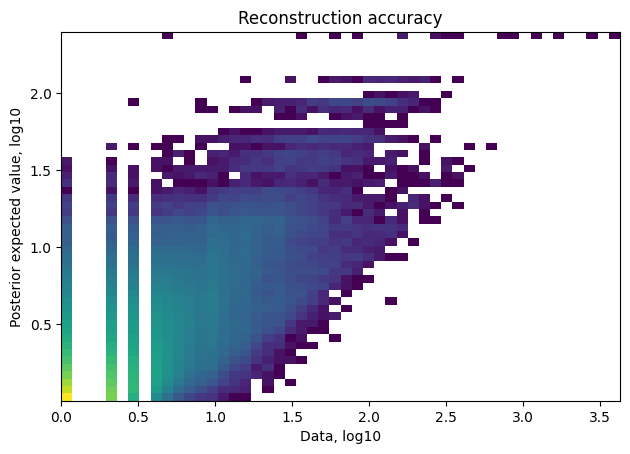

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

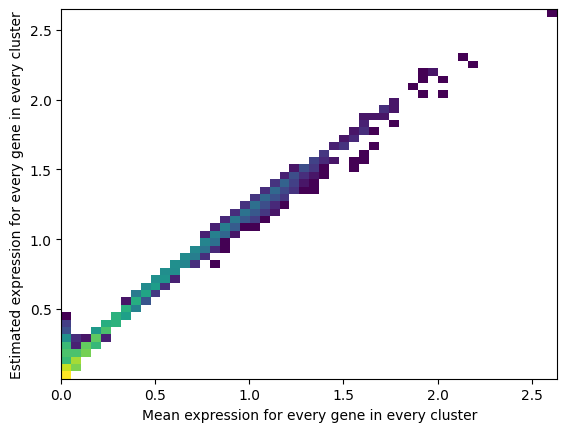

In [26]:
mod.plot_QC()

In [27]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}' 
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}' 
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,APC_cycling,APC_dorsal,APC_ventral,AST,COP
gene_ids,,,,,
ENSG00000237491,0.059154,0.049867,0.039903,0.057072,0.043117
ENSG00000228794,0.029421,0.029714,0.038207,0.089715,0.021851
ENSG00000187634,0.138335,0.095160,0.089274,0.810374,0.010917
ENSG00000188976,0.048977,0.026649,0.044097,0.115944,0.074353
ENSG00000187583,0.459522,0.272320,0.457027,0.898942,0.318279


# Cell2location: spatial mapping <a class="anchor" id="Cell2location:-spatial-mapping"></a>

<div class="alert alert-block alert-message">
<b>Find shared genes and prepare anndata.</b>
Subset both anndata and reference signatures:
</div>

In [28]:
adata_ref

AnnData object with n_obs × n_vars = 14846 × 11375
    obs: 'Sample', 'batch', 'sample2', 'celltype', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'feature_types', 'SYMBOL', 'n_cells', 'nonz_mean'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod'
    varm: 'means_per_cluster_mu_fg', 'q05_per_cluster_mu_fg', 'q95_per_cluster_mu_fg', 'stds_per_cluster_mu_fg'

In [29]:
adata_bgi

View of AnnData object with n_obs × n_vars = 17032 × 21008
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y'
    var: 'name', 'SYMBOL', 'MT_gene'
    obsm: 'X_cod', 'spatial', 'MT'

In [30]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_bgi.var_names, inf_aver.index)
adata_bgi = adata_bgi[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_bgi, batch_key=None)

In [31]:
# create and train the model
mod = cell2location.models.Cell2location(
    adata_bgi, 
    cell_state_df=inf_aver, 
    # the expected average cell abundance: tissue-dependent 
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=3,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
) 
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.2.0.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 17032 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 10324 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10000` reached.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfo

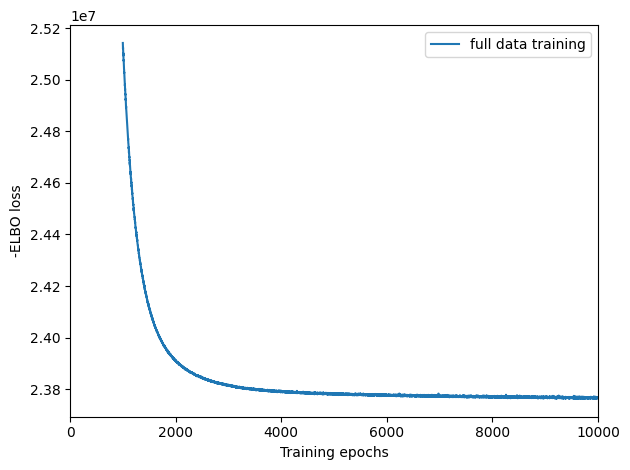

In [32]:
mod.train(max_epochs=10000, 
          # train using full data (batch_size=None)
          batch_size=None, 
          # use all data points in training because 
          # we need to estimate cell abundance at all locations
          train_size=1,
          #use_gpu=True,
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training']);

In [33]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_bgi = mod.export_posterior(
    adata_bgi, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs} #, 'use_gpu': True
)
# add 5% quantile, representing confident cell abundance, 'at least this amount is present', 
# to adata.obs with nice names for plotting
adata_bgi.obs[adata_bgi.uns['mod']['factor_names']] = adata_bgi.obsm['q05_cell_abundance_w_sf']

# Save model
mod.save(f"{run_name}", overwrite=True)

# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_bgi)


Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

# Estimate cell-type specific expression of every gene in the spatial data

In [34]:
expected_dict = mod.module.model.compute_expected_per_cell_type(
    mod.samples["post_sample_q05"], mod.adata_manager
)

# Add to anndata layers
for i, n in enumerate(mod.factor_names_):
    adata_bgi.layers[n] = expected_dict['mu'][i]

In [35]:
# Save anndata object with results
adata_file = f"{run_name}/sp_gw16.h5ad"
adata_bgi.write(adata_file)
adata_file

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis/cell2location_map/sp_gw16.h5ad'

In [36]:
adata_bgi

AnnData object with n_obs × n_vars = 17032 × 10324
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', '_indices', '_scvi_batch', '_scvi_labels', 'APC_cycling', 'APC_dorsal', 'APC_ventral', 'AST', 'COP', 'EC', 'ExN_immature_1', 'ExN_immature_2', 'ExN_immature_3', 'ExN_mature_1', 'ExN_mature_2', 'ExN_mature_3', 'ExN_naive', 'ExN_ventral', 'FP', 'IPC', 'InN_immature_1', 'InN_immature_2', 'InN_mature_1', 'InN_mature_2', 'InN_naive', 'InN_ventral_1', 'InN_ventral_2', 'InN_ventral_3', 'MFOL', 'MN1', 'MN2', 'MOL', 'MP', 'Microglia', 'NPC', 'NPC_proliferative', 'OPC', 'PC', 'RP', 'VLMC'
    var: 'name', 'SYMBOL', 'MT_gene'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'mod'
    obsm: 'X_cod', 'spatial', 'MT', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf'
    layers: 'APC_cycling', 'APC_dorsal', 'APC_ventral', 'AST', 'COP', 'EC', 'ExN_immature_1', 'ExN_immature_2', 'ExN_immature_3', 'ExN_m

In [ ]:
adata_bgi = sc.read_h5ad('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/cell2location3/results/hsc_analysis/cell2location_map/sp_gw16.h5ad')
adata_bgi

# Collect ncem anndata object

In [37]:
cell_types = np.unique(adata_ref.obs['celltype'])
cell_types = cell_types[~np.isin(cell_types, ['EC'])]
prop = adata_bgi.obs[cell_types]
cell_expression = []
node_types = []
proportions = []
spatial = []
for i, ct in enumerate(cell_types):
    proportions.append(prop)
    cell_expression.append(adata_bgi.layers[ct].toarray())
    nt = np.zeros((prop.shape[0], len(cell_types)))
    nt[:, i] = 1
    node_types.append(nt)
    spatial.append(adata_bgi.obsm['spatial'])
    
proportions = pd.DataFrame(np.concatenate(proportions), columns=cell_types)
cell_expression = pd.DataFrame(np.concatenate(cell_expression), columns=adata_bgi.var_names)
node_types = pd.DataFrame(np.concatenate(node_types), columns=cell_types)
spatial = pd.DataFrame(np.concatenate(spatial))

In [38]:
from anndata import AnnData
ad = AnnData(cell_expression)
ad.obsm['proportions'] = np.array(proportions)
ad.obsm['node_types'] = np.array(node_types)
ad.obsm['spatial'] = np.array(spatial)

ad.uns["node_type_names"] = {x: x for x in cell_types}
ad.var_names = adata_bgi.var['SYMBOL'].values

In [39]:
ad

AnnData object with n_obs × n_vars = 596120 × 10324
    uns: 'node_type_names'
    obsm: 'proportions', 'node_types', 'spatial'

h_0 = pd.DataFrame(ad.obsm['node_types'], columns=list(ad.uns['node_type_names'].values()))
target_type = pd.DataFrame(np.array(h_0.idxmax(axis=1)), columns=["target_cell"]).reset_index()
ad.obs = target_type

In [40]:
ad.write("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/NCEM/data/GW16.h5ad")

In [41]:
"SLC6A1" in ad.var_names

True